# Simplified Presentation Map Generator

This notebook creates minimalist world maps showing presentation locations. Simply update the locations list in cell 3 to add new cities, then run all cells to generate light and dark theme SVG maps.

## Quick Start:
1. Update locations in the list below
2. Run all cells
3. Maps will be saved as `assets/img/presentation_map_light.svg` and `assets/img/presentation_map_dark.svg`

In [1]:
# Import all required libraries

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Configuration - Add Your Locations Here

Update the list below with your presentation cities. Format: `(city, country)`

In [2]:
# Define your presentation locations here
# Format: (city, country, latitude, longitude)
LOCATIONS = [
    ("Jena", "Germany", 50.9275, 11.5864),
    ("Nara", "Japan", 34.6851, 135.8048),
    ("London", "United Kingdom", 51.5074, -0.1278),
    ("Vientiane", "Laos", 17.9757, 102.6331),
    ("Copenhagen", "Denmark", 55.6761, 12.5683),
    ("Vienna", "Austria", 48.2082, 16.3738),
    ("Cape Town", "South Africa", -33.9249, 18.4241),
    # Add more locations here as needed:
    # ("Paris", "France", 48.8566, 2.3522),
    # ("New York", "United States", 40.7128, -74.0060),
]

# Manual country mapping for country borders
COUNTRY_MAPPING = {
    "Germany": "Germany",
    "Japan": "Japan", 
    "United Kingdom": "United Kingdom",
    "Laos": "Laos",
    "Denmark": "Denmark",
    "Austria": "Austria",
    "South Africa": "South Africa",
    # Add more countries here as needed:
    # "France": "France",
    # "United States": "United States of America",  # Note: Natural Earth uses full name
}

print(f"✓ Configured {len(LOCATIONS)} presentation locations")
for city, country, lat, lon in LOCATIONS:
    print(f"  • {city}, {country} ({lat:.4f}, {lon:.4f})")


✓ Configured 7 presentation locations
  • Jena, Germany (50.9275, 11.5864)
  • Nara, Japan (34.6851, 135.8048)
  • London, United Kingdom (51.5074, -0.1278)
  • Vientiane, Laos (17.9757, 102.6331)
  • Copenhagen, Denmark (55.6761, 12.5683)
  • Vienna, Austria (48.2082, 16.3738)
  • Cape Town, South Africa (-33.9249, 18.4241)


## Map Generation Functions

These functions create the minimalist world maps with your presentation locations.

In [3]:
def create_presentation_map(locations, theme='light', figsize=(16, 2), dpi=300, lat_limits=None):
    """
    Create a minimalist world map with presentation locations
    
    Args:
        locations: List of (city, country, lat, lon) tuples
        theme: 'light' or 'dark'
        figsize: Figure size tuple
        dpi: Resolution
        lat_limits: Tuple of (min_lat, max_lat) to limit the vertical extent of the map
    
    Returns:
        fig, ax: Matplotlib figure and axis objects
    """
    # Create figure with Equal Earth projection (equal-area: countries shown at true relative size)
    fig = plt.figure(figsize=figsize, dpi=dpi, facecolor='none')
    projection = ccrs.EqualEarth()
    ax = fig.add_subplot(1, 1, 1, projection=projection)
    
    # Always use set_global() to preserve Equal Earth projection's curved edges,
    # then constrain latitude by adjusting y-limits in projected coordinates
    ax.set_global()
    if lat_limits:
        min_lat, max_lat = lat_limits
        y_min = projection.transform_point(0, min_lat, ccrs.PlateCarree())[1]
        y_max = projection.transform_point(0, max_lat, ccrs.PlateCarree())[1]
        ax.set_ylim(y_min, y_max)
    
    # Theme colors
    if theme == 'dark':
        land_color = '#2c3e50'
        ocean_color = '#1e2a3a'
        coastline_color = '#34495e'
        border_color = '#4a90e2'
        dot_color = '#5dade2'
    else:
        land_color = 'white'
        ocean_color = '#f0f8fc'
        coastline_color = '#000000'
        border_color = 'black'
        dot_color = '#2698ba'  # Website blue
    
    # Add map features
    ax.add_feature(cfeature.LAND, color=land_color, edgecolor='none')
    ax.add_feature(cfeature.OCEAN, color=ocean_color, edgecolor='none')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.2, color=coastline_color, alpha=0.8)
    
    # Add country borders for presentation countries
    try:
        # Get unique countries from locations
        countries_to_show = set(COUNTRY_MAPPING.get(loc[1], loc[1]) for loc in locations)
        
        # Load Natural Earth country boundaries
        shpfilename = shapereader.natural_earth(resolution='50m', 
                                               category='cultural', 
                                               name='admin_0_countries')
        
        for country in shapereader.Reader(shpfilename).records():
            country_name = country.attributes.get('NAME', '')
            if country_name in countries_to_show:
                ax.add_geometries([country.geometry], ccrs.PlateCarree(),
                                facecolor='none', 
                                edgecolor=border_color, 
                                linewidth=0.4,
                                alpha=0.9,
                                zorder=3)
    except Exception as e:
        print(f"Note: Could not load country boundaries: {e}")
    
    # Add location dots
    for city, country, lat, lon in locations:
        x, y = ax.projection.transform_point(lon, lat, ccrs.PlateCarree())
        ax.plot(x, y, 'o', color=dot_color, markersize=4, 
                alpha=0.9, zorder=10, transform=ax.projection)
    
    # Clean styling
    ax.spines['geo'].set_linewidth(0.3)
    ax.spines['geo'].set_edgecolor(border_color)
    ax.set_xticks([])
    ax.set_yticks([])
    
    return fig, ax

print("✓ Map creation function defined with Equal Earth projection")


✓ Map creation function defined with Equal Earth projection


## Generate and Save Maps

Create both light and dark theme maps and save them as SVG files.

Using latitude limits: -42° to 65°N for a more focused view
Creating light theme map...


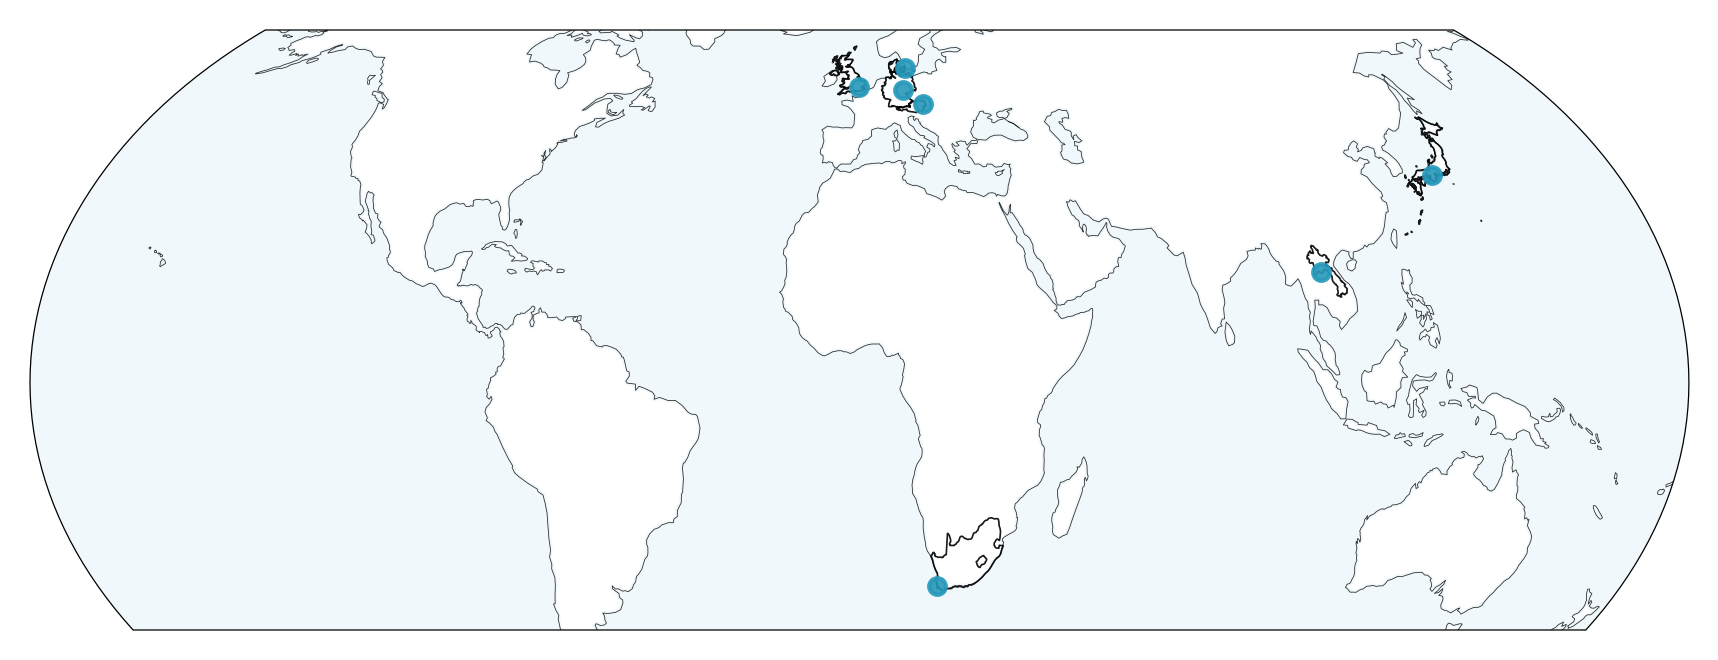

Creating dark theme map...


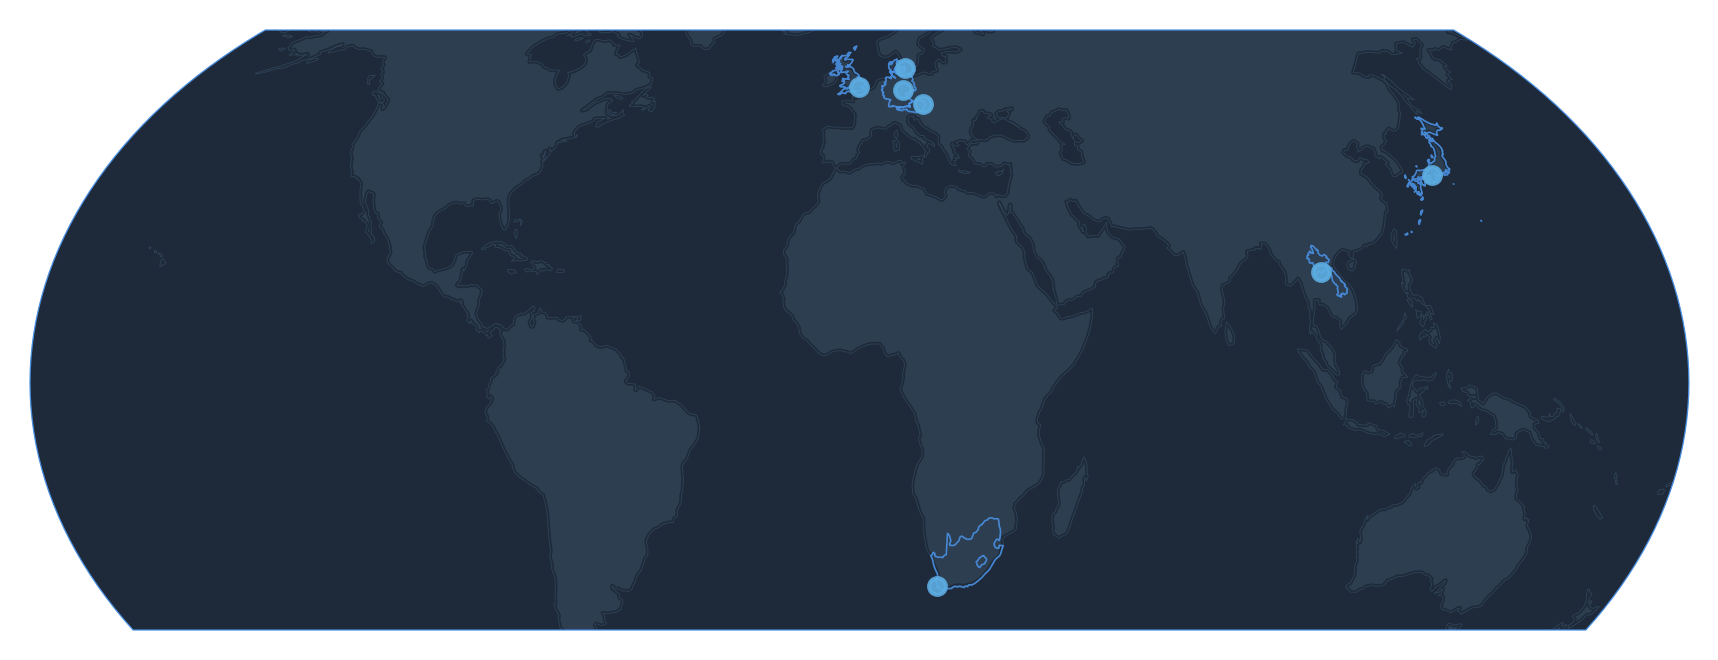


✅ MAPS GENERATED SUCCESSFULLY!
Light theme: assets/img/presentation_map_light.svg (449,608 bytes)
Dark theme:  assets/img/presentation_map_dark.svg (449,608 bytes)
Latitude range: -42° to 65°N

Total locations plotted: 7
  • Jena, Germany
  • Nara, Japan
  • London, United Kingdom
  • Vientiane, Laos
  • Copenhagen, Denmark
  • Vienna, Austria
  • Cape Town, South Africa


In [4]:
# Create and save both light and dark theme maps
import os

# Ensure assets/img directory exists
os.makedirs('assets/img', exist_ok=True)

# Calculate appropriate latitude limits based on your locations
# Locations span from Cape Town (-34°S) to Copenhagen/London (~56°N)
# Adding some padding for better visualization
lat_limits = (-42, 65)  # Extended south to include Cape Town (South Africa)

print(f"Using latitude limits: {lat_limits[0]}° to {lat_limits[1]}°N for a more focused view")

# Generate light theme map
print("Creating light theme map...")
fig_light, ax_light = create_presentation_map(LOCATIONS, theme='light', lat_limits=lat_limits)
plt.tight_layout(pad=0)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Save light theme
light_path = 'assets/img/presentation_map_light.svg'
plt.savefig(light_path, 
            format='svg',
            bbox_inches='tight',
            pad_inches=0.1,
            transparent=True,
            facecolor='none')
plt.show()
plt.close()

# Generate dark theme map
print("Creating dark theme map...")
fig_dark, ax_dark = create_presentation_map(LOCATIONS, theme='dark', lat_limits=lat_limits)
plt.tight_layout(pad=0)
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Save dark theme
dark_path = 'assets/img/presentation_map_dark.svg'
plt.savefig(dark_path, 
            format='svg',
            bbox_inches='tight',
            pad_inches=0.1,
            transparent=True,
            facecolor='none')
plt.show()
plt.close()

# Check file sizes
light_size = os.path.getsize(light_path) if os.path.exists(light_path) else 0
dark_size = os.path.getsize(dark_path) if os.path.exists(dark_path) else 0

print("\n✅ MAPS GENERATED SUCCESSFULLY!")
print("="*50)
print(f"Light theme: {light_path} ({light_size:,} bytes)")
print(f"Dark theme:  {dark_path} ({dark_size:,} bytes)")
print(f"Latitude range: {lat_limits[0]}° to {lat_limits[1]}°N")
print(f"\nTotal locations plotted: {len(LOCATIONS)}")
for city, country, lat, lon in LOCATIONS:
    print(f"  • {city}, {country}")
